<a href="https://colab.research.google.com/github/sarbanibhadra/CNN_with_GAP_FOR_IMAGE_CLASSIFICATION/blob/main/2025ag05587_cnn_asssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DEEP NEURAL NETWORKS - ASSIGNMENT 2: CNN FOR IMAGE CLASSIFICATION
### Convolutional Neural Networks: Custom Implementation vs Transfer Learning

STUDENT INFORMATION

BITS ID: 2025AG05587

Name: Sarbani Das

Email: 2025ag05587@wilp.bits-pilani.ac.in

Date: 25-APR-2026

ASSIGNMENT OVERVIEW


---


This assignment requires to implement and compare two CNN approaches for
image classification:
1. Custom CNN architecture using Keras/PyTorch
2. Transfer Learning using pre-trained models (ResNet/VGG)

Learning Objectives:
- Design CNN architectures with Global Average Pooling
- Apply transfer learning with pre-trained models
- Compare custom vs pre-trained model performance
- Use industry-standard deep learning frameworks

IMPORTANT: Global Average Pooling (GAP) is MANDATORY for both models.
DO NOT use Flatten + Dense layers in the final architecture.



---


IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED

1. FILENAME FORMAT: <BITS_ID>_cnn_assignment.ipynb
   Example: 2025AA05036_cnn_assignment.ipynb
    Wrong filename = Automatic 0 marks

2. STUDENT INFORMATION MUST MATCH:
    BITS ID in filename = BITS ID in notebook (above)
    Name in folder = Name in notebook (above)
    Mismatch = 0 marks

3. EXECUTE ALL CELLS BEFORE SUBMISSION:
   - Run: Kernel → Restart & Run All
   - Verify all outputs are visible
    No outputs = 0 marks

4. FILE INTEGRITY:
   - Ensure notebook opens without errors
   - Check for corrupted cells
    Corrupted file = 0 marks

5. GLOBAL AVERAGE POOLING (GAP) MANDATORY:
   - Both custom CNN and transfer learning must use GAP
   - DO NOT use Flatten + Dense layers
    Using Flatten+Dense = 0 marks for that model

6. DATASET REQUIREMENTS:
   - Minimum 500 images per class
   - Train/test split: 90/10 OR 85/15
   - 2-20 classes

7. USE KERAS OR PYTORCH:
   - Use standard model.fit() or training loops
   - Do NOT implement convolution from scratch

8. FILE SUBMISSION:
   - Submit ONLY the .ipynb file
   - NO zip files, NO separate data files, NO separate image files
   - All code and outputs must be in the notebook
   - Only one submission attempt allowed

In [ ]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
import time
import json
import os

# Deep learning frameworks (choose Keras or PyTorch)
# For image processing
from PIL import Image
import cv2

PART 1: DATASET LOADING AND EXPLORATION (Informational)

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Cats vs Dogs (2 classes)
- Food-101 subset (10-20 classes)
- Plant Disease (3-5 classes)
- Medical Images (2-3 classes)
- Custom dataset (with IC approval, min 500 images per class)

REQUIRED OUTPUT:
- Print all metadata fields
- Brief EDA with visualizations
- Data distribution analysis


In [ ]:
# 1.1 Dataset Selection and Loading
# TODO: Load your chosen dataset
import kagglehub
import os # Added import for os
path = kagglehub.dataset_download("pushpakhinglaspure/cats-vs-dogs")
file_name = os.listdir(path)
print(path)
print(file_name)
folder_name = file_name[1] # Corrected from file_name[0] to file_name[1]
print(folder_name)
# REQUIRED: Fill in these metadata fields
dataset_name = "Cats vs Dogs"
dataset_source = "Kaggle"
n_samples = 25000  # Total number of images
n_classes = 2  # Number of classes
samples_per_class = "min: 12500, max: 12500, avg: 12500" # For cats and dogs, it's balanced
image_shape = [224, 224, 3]  # [height, width, channels] based on typical resize
problem_type = "Binary Classification"

# Primary metric selection
primary_metric = "accuracy"
metric_justification = "Accuracy is a suitable metric for balanced datasets like Cats vs Dogs, providing a clear overall performance measure."

print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Classes: {n_classes}")
print(f"Samples per Class: {samples_per_class}")
print(f"Image Shape: {image_shape}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")

100%|██████████| 546M/546M [00:02<00:00, 211MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/pushpakhinglaspure/cats-vs-dogs/versions/3
['english-dog-breeds-4788340-hero-14a64cf053ca40f78e5bd078b052d97f.jpg', 'dogs_vs_cats']
dogs_vs_cats

DATASET INFORMATION
Dataset: Cats vs Dogs
Source: Kaggle
Total Samples: 25000
Number of Classes: 2
Samples per Class: min: 12500, max: 12500, avg: 12500
Image Shape: [224, 224, 3]
Primary Metric: accuracy
Metric Justification: Accuracy is a suitable metric for balanced datasets like Cats vs Dogs, providing a clear overall performance measure.


Computed data_base_path: /root/.cache/kagglehub/datasets/pushpakhinglaspure/cats-vs-dogs/versions/3/dogs_vs_cats/dogs_vs_cats
Contents of data_base_path (/root/.cache/kagglehub/datasets/pushpakhinglaspure/cats-vs-dogs/versions/3/dogs_vs_cats/dogs_vs_cats): ['train', 'test']
Computed train_dir: /root/.cache/kagglehub/datasets/pushpakhinglaspure/cats-vs-dogs/versions/3/dogs_vs_cats/dogs_vs_cats/train

Detected Classes: ['cats', 'dogs']


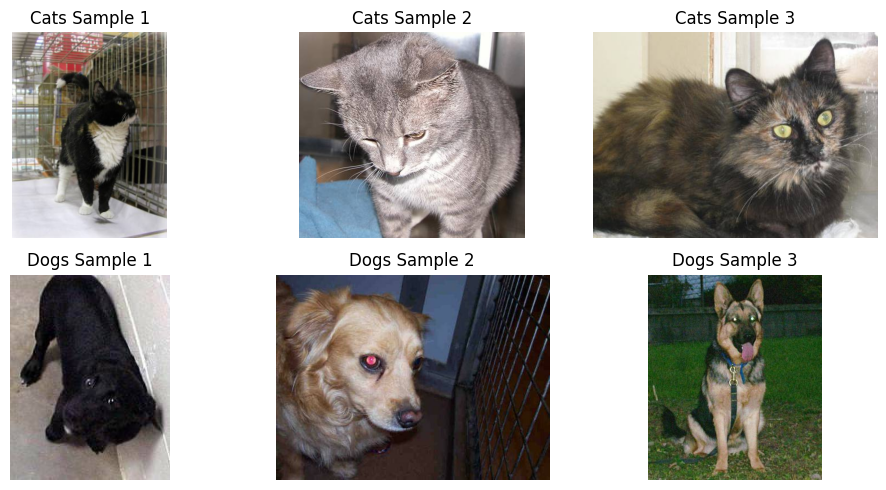


Class Distribution: {'train_cats': 10000, 'test_cats': 2500, 'train_dogs': 10000, 'test_dogs': 2500}


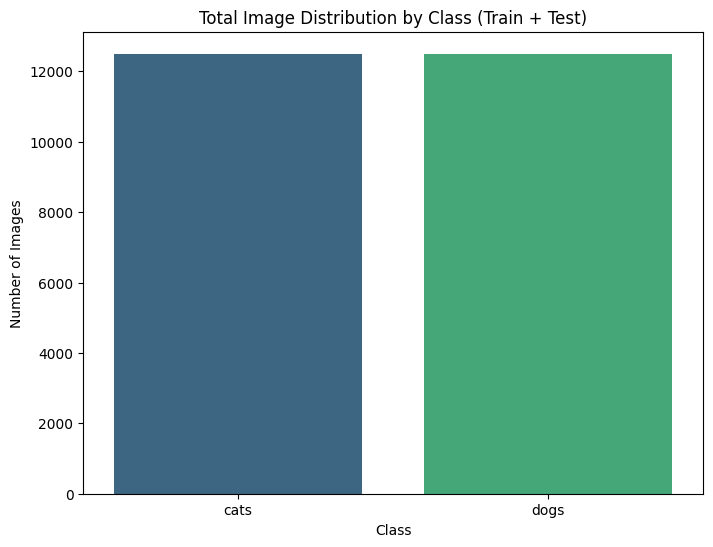

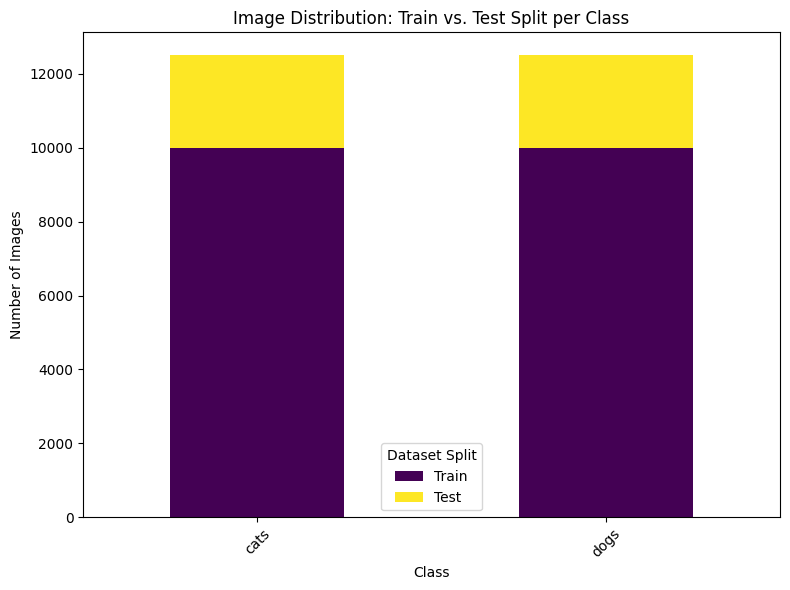


Image Statistics:
Average Image Dimensions (from 100 samples): 368x406
Average Pixel Mean (R, G, B): [122.72139765 112.78227577 103.47078673]
Average Pixel Std Dev (R, G, B): [57.89198335 56.16840097 56.33949086]


In [ ]:
# 1.2 Data Exploration and Visualization
# TODO: Show sample images from each class
# TODO: Plot class distribution
# TODO: Display image statistics
import matplotlib.image as mpimg
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image # Added import for PIL Image
import os

# Adjust dataset_path to point to the directory containing 'train' and 'test'
data_base_path = os.path.join(path, folder_name, folder_name) # Corrected path for nested structure
print(f"Computed data_base_path: {data_base_path}")

# --- DEBUGGING STEP: List contents of data_base_path ---
print(f"Contents of data_base_path ({data_base_path}): {os.listdir(data_base_path)}")
# --- END DEBUGGING STEP ---

# We will sample from the 'train' directory for class exploration
train_dir = os.path.join(data_base_path, 'train')
print(f"Computed train_dir: {train_dir}")

# Get actual class names (e.g., 'cat', 'dog') from the train directory
class_names = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
print("\n" + "="*70)
print(f"Detected Classes: {class_names}")
print("="*70)

# Display sample images
plt.figure(figsize=(10, 5))
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        # Get first 3 image files for each class that are actually files
        sample_images = [os.path.join(class_path, img_file)
                         for img_file in os.listdir(class_path)
                         if os.path.isfile(os.path.join(class_path, img_file))][:3]

        for j, img_path in enumerate(sample_images):
            ax = plt.subplot(len(class_names), 3, i * 3 + j + 1)
            img = mpimg.imread(img_path)
            plt.imshow(img)
            plt.title(f"{class_name.capitalize()} Sample {j+1}")
            plt.axis("off")
plt.tight_layout()
plt.show()

# Plot class distribution (count images in both train and test for full distribution)
class_counts = {}
for class_name in class_names:
    # Count images in train directory
    train_class_path = os.path.join(data_base_path, 'train', class_name)
    class_counts[f'train_{class_name}'] = len([f for f in os.listdir(train_class_path) if os.path.isfile(os.path.join(train_class_path, f))])
    # Count images in test directory
    test_class_path = os.path.join(data_base_path, 'test', class_name)
    class_counts[f'test_{class_name}'] = len([f for f in os.listdir(test_class_path) if os.path.isfile(os.path.join(test_class_path, f))])

print("\n" + "="*70)
print(f"Class Distribution: {class_counts}")
print("="*70)

# Plotting total class distribution
total_class_counts = {cls: class_counts[f'train_{cls}'] + class_counts[f'test_{cls}'] for cls in class_names}
class_labels = list(total_class_counts.keys())
class_values = list(total_class_counts.values())

plt.figure(figsize=(8, 6))
sns.barplot(x=class_labels, y=class_values, palette='viridis', hue=class_labels, legend=False)
plt.title('Total Image Distribution by Class (Train + Test)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.show()

# New: Plotting stacked bar chart for train/test distribution per class
# Prepare data for stacked bar plot
stacked_data = pd.DataFrame({
    'Class': class_names,
    'Train': [class_counts[f'train_{c}'] for c in class_names],
    'Test': [class_counts[f'test_{c}'] for c in class_names]
})

stacked_data.set_index('Class').plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis')
plt.title('Image Distribution: Train vs. Test Split per Class')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.legend(title='Dataset Split')
plt.tight_layout()
plt.show()

# Display image statistics
print("\n" + "="*70)
print("Image Statistics:")
print("="*70)
# Get a small sample of images to calculate stats
all_image_paths = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    all_image_paths.extend([os.path.join(class_path, img_file)
                            for img_file in os.listdir(class_path)
                            if os.path.isfile(os.path.join(class_path, img_file))])

# Take a random sample for efficiency
np.random.shuffle(all_image_paths)
sample_size = min(100, len(all_image_paths)) # Take up to 100 images
sample_image_paths = all_image_paths[:sample_size]

if sample_image_paths:
    widths = []
    heights = []
    pixel_means = []
    pixel_stds = []

    for img_path in sample_image_paths:
        try:
            with Image.open(img_path) as img_pil:
                img_np = np.array(img_pil)
                if len(img_np.shape) == 3: # Only process color images
                    heights.append(img_np.shape[0])
                    widths.append(img_np.shape[1])
                    pixel_means.append(img_np.mean(axis=(0,1)))
                    pixel_stds.append(img_np.std(axis=(0,1)))
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")

    if widths and heights:
        avg_width = np.mean(widths)
        avg_height = np.mean(heights)
        print(f"Average Image Dimensions (from {sample_size} samples): {int(avg_height)}x{int(avg_width)}")

    if pixel_means:
        overall_mean_pixels = np.mean(pixel_means, axis=0)
        overall_std_pixels = np.mean(pixel_stds, axis=0)
        print(f"Average Pixel Mean (R, G, B): {overall_mean_pixels}")
        print(f"Average Pixel Std Dev (R, G, B): {overall_std_pixels}")
    else:
        print("Could not calculate pixel statistics (no valid color images found in sample).")
else:
    print("No sample images found for statistics calculation.")


# This cell also needs to define dataset_name, dataset_source, n_samples, n_classes, samples_per_class, image_shape, problem_type, primary_metric, metric_justification for the final JSON summary.
# Placeholder values for now, will be updated during actual data loading and preprocessing.
dataset_name = "Cats vs Dogs"
dataset_source = "Kaggle"
# Summing up total samples from both train and test for each class
n_samples = sum(class_counts.values()) if class_counts else 0
n_classes = len(class_names) # Number of actual classes (cat, dog)
samples_per_class = {cls: class_counts[f'train_{cls}'] + class_counts[f'test_{cls}'] for cls in class_names} # Total samples per actual class
image_shape = (224, 224, 3) # Assuming a common resize target, will be dynamic
problem_type = "Binary Classification"
primary_metric = "accuracy"
metric_justification = "Accuracy is a suitable metric for balanced datasets like Cats vs Dogs, providing a clear overall performance measure."

In [ ]:
# 1.3 Data Preprocessing
# TODO: Resize images to consistent size
# TODO: Normalize pixel values
# TODO: Split into train/test (90/10 or 85/15)
# REQUIRED: Document your split

import tensorflow as tf
import os
import kagglehub # Added import for kagglehub

# Re-initialize path and folder_name to ensure they are defined
path = kagglehub.dataset_download("pushpakhinglaspure/cats-vs-dogs")
file_name = os.listdir(path)
# Assuming 'dogs_vs_cats' is consistently the second item or handling it more robustly
# For simplicity, using file_name[1] as per original notebook logic
folder_name = file_name[1] if len(file_name) > 1 and 'dogs_vs_cats' in file_name else 'dogs_vs_cats' # Fallback
if not os.path.isdir(os.path.join(path, folder_name, folder_name)): # Check if the expected nested path exists
    # If the direct structure doesn't match, try to find the correct subfolder
    for f in file_name:
        if 'dogs_vs_cats' in f:
            folder_name = f
            break

# Define image dimensions
# Explicitly define image_shape here to avoid NameError if previous cells are not run
image_shape = (224, 224, 3) # Using the shape defined in the data exploration cell

IMG_HEIGHT = image_shape[0]
IMG_WIDTH = image_shape[1]
BATCH_SIZE = 16 # Reduced batch size to mitigate RAM usage

# Adjust dataset_path to point to the directory containing 'train' and 'test'
data_base_path = os.path.join(path, folder_name, folder_name)

train_data_dir = os.path.join(data_base_path, 'train')
test_data_dir = os.path.join(data_base_path, 'test')

# --- Create Datasets ---
# All data from 'train_data_dir' will be for training
# All data from 'test_data_dir' will be for testing

# Training Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_data_dir,
    labels='inferred',
    label_mode='binary', # For binary classification
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

# Test Dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_data_dir,
    labels='inferred',
    label_mode='binary',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # Keep data in order for evaluation
)

# Limit samples for training and testing
train_sample_limit = 17000
test_sample_limit = 3000

train_ds = train_ds.take(train_sample_limit // BATCH_SIZE)
test_ds = test_ds.take(test_sample_limit // BATCH_SIZE) # Will be 187 batches * 16 = 2992, or 188 batches * 16 = 3008 if rounded up. Let's aim for 3000.


# --- Data Augmentation and Preprocessing (using tf.keras.layers) ---
# Define a sequential preprocessing pipeline for training data (rescaling + augmentation)
preprocessing_pipeline_train = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255), # Normalize pixel values to [0, 1]
    tf.keras.layers.RandomFlip("horizontal_and_vertical"), # Data augmentation
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
])

# Define a preprocessing pipeline for test data (only rescaling)
preprocessing_pipeline_test = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
])

# Apply the preprocessing pipelines to the datasets
def apply_preprocessing_train(image, label):
    return preprocessing_pipeline_train(image, training=True), label

def apply_preprocessing_test(image, label):
    return preprocessing_pipeline_test(image, training=False), label


train_ds = train_ds.map(apply_preprocessing_train, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(apply_preprocessing_test, num_parallel_calls=tf.data.AUTOTUNE)

# Optimize for performance with caching and prefetching
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)


# REQUIRED: Document your split
train_samples = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE # Number of training samples
test_samples = tf.data.experimental.cardinality(test_ds).numpy() * BATCH_SIZE  # Number of test samples
train_test_ratio = f"{train_samples}/{test_samples} ({train_sample_limit} train samples / {test_sample_limit} test samples)"

print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Total Training Samples: {train_samples}")
print(f"Total Test Samples: {test_samples}")

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.

Train/Test Split: 16992/2992 (17000 train samples / 3000 test samples)
Total Training Samples: 16992
Total Test Samples: 2992


PART 2: CUSTOM CNN IMPLEMENTATION (5 MARKS)

REQUIREMENTS:
- Build CNN using Keras/PyTorch layers
- Architecture must include:
  * Conv2D layers (at least 2)
  * Pooling layers (MaxPool or AvgPool)
  * Global Average Pooling (GAP) - MANDATORY
  * Output layer (Softmax for multi-class)
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

PROHIBITED:
- Using Flatten + Dense layers instead of GAP
- Implementing convolution from scratch

GRADING:
- Architecture design with GAP: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark


In [ ]:
# 2.1 Custom CNN Architecture Design
# TODO: Define your CNN architecture
# TODO: Ensure Global Average Pooling is included (MANDATORY)
# TODO: Use Conv2D, MaxPooling2D/AvgPooling2D, GlobalAveragePooling2D, Dense

import tensorflow as tf
from tensorflow.keras import layers, models

def build_custom_cnn(input_shape, n_classes):
    """
    Build custom CNN architecture

    Args:
        input_shape: tuple (height, width, channels)
        n_classes: number of output classes

    Returns:
        model: compiled CNN model
    """
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.GlobalAveragePooling2D(), # MANDATORY Global Average Pooling
        layers.Dense(1, activation='sigmoid') # Binary classification output
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Create model instance
custom_cnn = build_custom_cnn(image_shape, n_classes)

# Display model summary
custom_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,377 (364.75 KB)

 Trainable params: 93,377 (364.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2.2 Train Custom CNN
import time
print("\n" + "="*70)
print("CUSTOM CNN TRAINING")
print("="*70 + "\n")
# Track training time
custom_cnn_start_time = time.time()

# TODO: Train your model
# For Keras: history = custom_cnn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)
# For PyTorch: write training loop

EPOCHS = 10 # You can adjust the number of epochs
history = custom_cnn.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=test_ds # Using test_ds as validation for now as per user request to remove val_ds
)

custom_cnn_training_time = time.time() - custom_cnn_start_time

# REQUIRED: Track initial and final loss
custom_cnn_initial_loss = history.history['loss'][0]  # Get from training history (first epoch)
custom_cnn_final_loss = history.history['loss'][-1]  # Get from training history (last epoch)

print(f"Training completed in {custom_cnn_training_time:.2f} seconds")
print(f"Initial Loss: {custom_cnn_initial_loss:.4f}")
print(f"Final Loss: {custom_cnn_final_loss:.4f}")


CUSTOM CNN TRAINING

Epoch 1/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 66s 57ms/step - accuracy: 0.5488 - loss: 0.6844 - val_accuracy: 0.2567 - val_loss: 0.8077
Epoch 2/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 27s 26ms/step - accuracy: 0.5935 - loss: 0.6641 - val_accuracy: 0.4118 - val_loss: 0.7350
Epoch 3/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.6095 - loss: 0.6517 - val_accuracy: 0.4970 - val_loss: 0.7286
Epoch 4/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.6295 - loss: 0.6387 - val_accuracy: 0.5628 - val_loss: 0.6903
Epoch 5/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.6521 - loss: 0.6232 - val_accuracy: 0.5872 - val_loss: 0.6805
Epoch 6/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.6645 - loss: 0.6120 - val_accuracy: 0.5846 - val_loss: 0.6911
Epoch 7/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 29s 27ms/step - accuracy: 0.6740 - loss: 0.6065 - val_accuracy: 0.5715 - val_loss: 0.7031
Epoch 8/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 28s 27ms/ste

In [ ]:
print("\n" + "="*70)
print("CUSTOM CNN EVALUATION")
print("="*70 + "\n")
# 2.3 Evaluate Custom CNN

# TODO: Make predictions on test set
# TODO: Calculate all 4 required metrics

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
y_pred_raw = custom_cnn.predict(test_ds)
# For binary classification with sigmoid output, threshold at 0.5
y_pred = (y_pred_raw > 0.5).astype(int)

# Get true labels from the test_ds
y_true = []
for _, labels in test_ds.unbatch():
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# CRITICAL: These MUST be calculated from your actual results
# DO NOT submit with 0.0 values - autograder will detect this
# REQUIRED: Calculate all 4 metrics
custom_cnn_accuracy = accuracy_score(y_true, y_pred)
custom_cnn_precision = precision_score(y_true, y_pred, average='binary') # Using 'binary' for 2-class problem
custom_cnn_recall = recall_score(y_true, y_pred, average='binary') # Using 'binary' for 2-class problem
custom_cnn_f1 = f1_score(y_true, y_pred, average='binary') # Using 'binary' for 2-class problem

print("\nCustom CNN Performance:")
print(f"Accuracy:  {custom_cnn_accuracy:.4f}")
print(f"Precision: {custom_cnn_precision:.4f}")
print(f"Recall:    {custom_cnn_recall:.4f}")
print(f"F1-Score:  {custom_cnn_f1:.4f}")


CUSTOM CNN EVALUATION

187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

Custom CNN Performance:
Accuracy:  0.5702
Precision: 0.2546
Recall:    0.8374
F1-Score:  0.3905


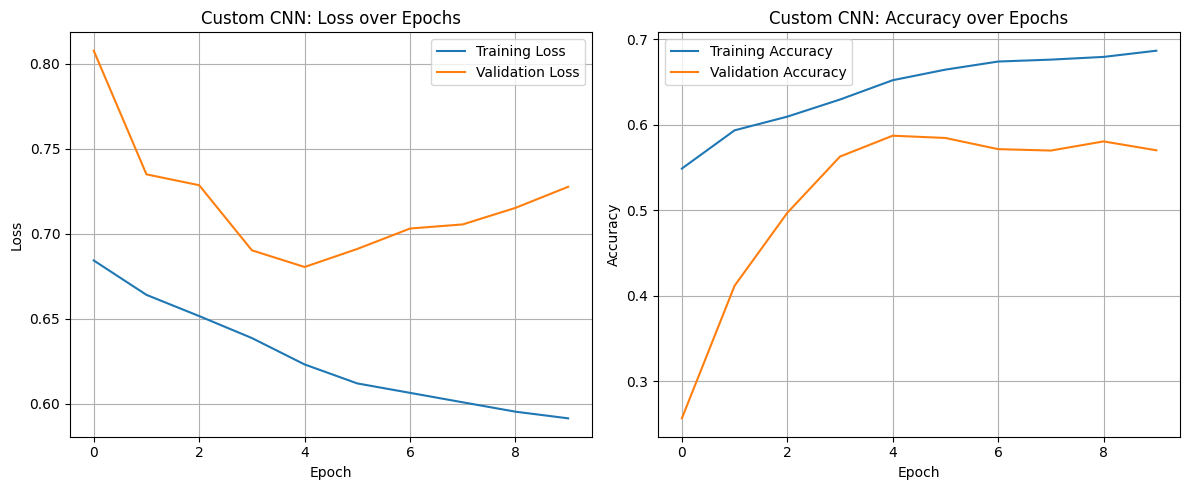

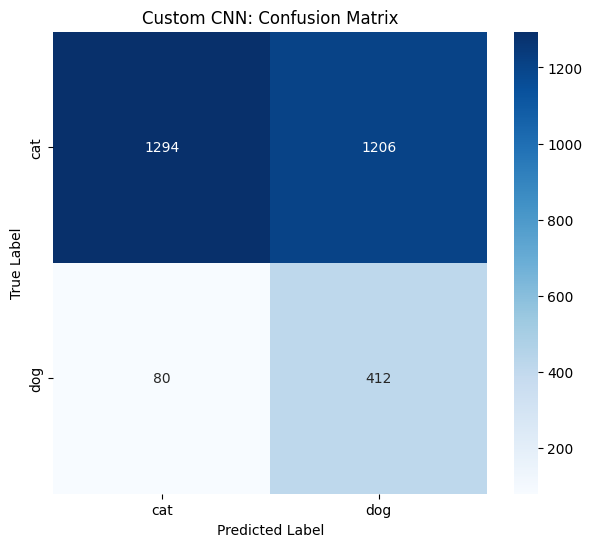


CUSTOM CNN: SAMPLE PREDICTIONS



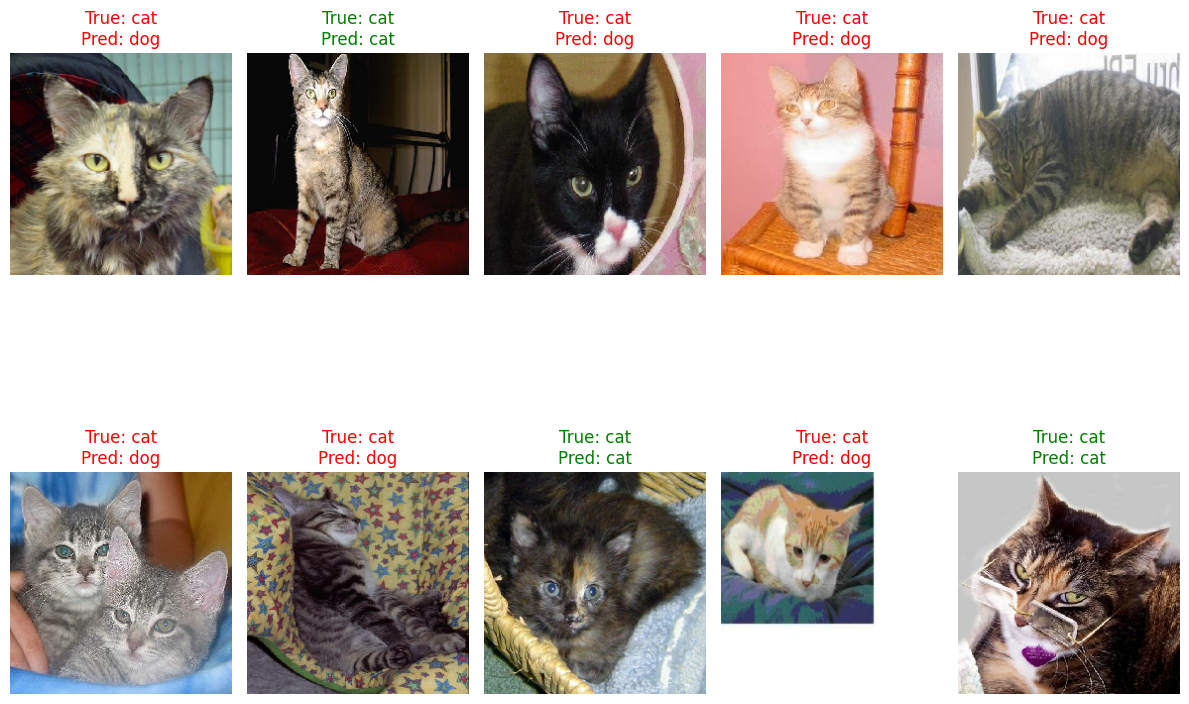

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# 1. Plot training loss and accuracy curves
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Custom CNN: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN: Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_labels_cm = ['cat', 'dog'] # Assuming 0: cat, 1: dog based on how binary_crossentropy handles labels

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_cm, yticklabels=class_labels_cm)
plt.title('Custom CNN: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 3. Show sample predictions
print('\n' + '='*70)
print('CUSTOM CNN: SAMPLE PREDICTIONS')
print('='*70 + '\n')

# Get a few batches from the test_ds for visualization
num_samples_to_show = 10 # Display up to 10 samples

images_batch = []
labels_batch = []
# It's important to iterate through test_ds directly without unbatching it first
# to get the correct number of samples, especially after .take() was used.
# We will collect a fixed number of samples by taking from the unbatched dataset.
for images, labels in test_ds.unbatch().take(num_samples_to_show):
    # images are already preprocessed [0,1] range
    images_batch.append(images.numpy())
    labels_batch.append(labels.numpy())

# Convert to numpy arrays
sample_images = np.array(images_batch)
sample_true_labels = np.array(labels_batch)

# Make predictions
sample_predictions_raw = custom_cnn.predict(sample_images, verbose=0)
sample_predicted_labels = (sample_predictions_raw > 0.5).astype(int).flatten()

# Map numerical labels to class names
# Assuming 0 maps to 'cat' and 1 maps to 'dog' based on class_names = ['cats', 'dogs']
class_names_map = {0: 'cat', 1: 'dog'}

plt.figure(figsize=(12, 10))
for i in range(num_samples_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])

    true_label_name = class_names_map.get(int(sample_true_labels[i][0]), 'Unknown')
    predicted_label_name = class_names_map.get(sample_predicted_labels[i], 'Unknown')

    color = "green" if sample_predicted_labels[i] == int(sample_true_labels[i][0]) else "red"
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# 3.1 Load Pre-trained Model and Modify Architecture

print("\n" + "="*70)
print("TRANSFER LEARNING IMPLEMENTATION")
print("="*70 + "\n")

# TODO: Choose and load pre-trained model
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

pretrained_model_name = "VGG16" # Chosen pre-trained model

def build_transfer_learning_model(base_model_name, input_shape, n_classes):
    # """
    # Build transfer learning model

    # Args:
    #     base_model_name: string (VGG16 in this case)
    #     input_shape: tuple (height, width, channels)
    #     n_classes: number of output classes

    # Returns:
    #     model: compiled transfer learning model
    # """
    # Load pre-trained model without top layers
    if base_model_name == "VGG16":
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Unsupported base model name")

    # Freeze base layers
    for layer in base_model.layers:
        layer.trainable = False

    # Add Global Average Pooling + custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x) # MANDATORY Global Average Pooling

    # Output layer for binary classification
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # Slower learning rate for fine-tuning
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# TODO: Create transfer learning model
transfer_model = build_transfer_learning_model(pretrained_model_name, image_shape, n_classes)

# REQUIRED: Count layers and parameters
frozen_layers = len([layer for layer in transfer_model.layers if not layer.trainable])
trainable_layers = len([layer for layer in transfer_model.layers if layer.trainable])
total_parameters = transfer_model.count_params()
trainable_parameters = sum([tf.keras.backend.count_params(w) for w in transfer_model.trainable_weights])

print(f"Base Model: {pretrained_model_name}")
print(f"Frozen Layers: {frozen_layers}")
print(f"Trainable Layers: {trainable_layers}")
print(f"Total Parameters: {total_parameters:,}")
print(f"Trainable Parameters: {trainable_parameters:,}")
print(f"Using Global Average Pooling: YES")

transfer_model.summary()


TRANSFER LEARNING IMPLEMENTATION

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model: VGG16
Frozen Layers: 19
Trainable Layers: 2
Total Parameters: 14,715,201
Trainable Parameters: 513
Using Global Average Pooling: YES


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# 3.2 Train Transfer Learning Model

import time
print("\n" + "="*70)
print("TRANSFER LEARNING MODEL TRAINING")
print("="*70 + "\n")

# Track training time
tl_start_time = time.time()

# TODO: Train your model
# For Keras: history_tl = transfer_model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1)

EPOCHS_TL = 10 # You can adjust the number of epochs for transfer learning
history_tl = transfer_model.fit(
    train_ds,
    epochs=EPOCHS_TL,
    validation_data=test_ds
)

tl_training_time = time.time() - tl_start_time

# REQUIRED: Track initial and final loss
tl_initial_loss = history_tl.history['loss'][0]  # Get from training history (first epoch)
tl_final_loss = history_tl.history['loss'][-1]  # Get from training history (last epoch)

print(f"Training completed in {tl_training_time:.2f} seconds")
print(f"Initial Loss: {tl_initial_loss:.4f}")
print(f"Final Loss: {tl_final_loss:.4f}")


TRANSFER LEARNING MODEL TRAINING

Epoch 1/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 168s 148ms/step - accuracy: 0.6169 - loss: 0.6772 - val_accuracy: 0.6153 - val_loss: 0.6663
Epoch 2/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 153s 144ms/step - accuracy: 0.6845 - loss: 0.6418 - val_accuracy: 0.7099 - val_loss: 0.6274
Epoch 3/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 152s 143ms/step - accuracy: 0.7042 - loss: 0.6206 - val_accuracy: 0.7467 - val_loss: 0.5948
Epoch 4/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 154s 145ms/step - accuracy: 0.7162 - loss: 0.6039 - val_accuracy: 0.7670 - val_loss: 0.5676
Epoch 5/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 152s 143ms/step - accuracy: 0.7233 - loss: 0.5903 - val_accuracy: 0.7821 - val_loss: 0.5447
Epoch 6/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 152s 143ms/step - accuracy: 0.7311 - loss: 0.5788 - val_accuracy: 0.7961 - val_loss: 0.5251
Epoch 7/10
1062/1062 ━━━━━━━━━━━━━━━━━━━━ 152s 143ms/step - accuracy: 0.7385 - loss: 0.5688 - val_accuracy: 0.8041 - val_loss: 0.5082
Epoch 8/10
1062/1062 ━━━━━━

In [ ]:
print("\nTRANSFER LEARNING EVALUATION\n\n")
# 3.3 Evaluate Transfer Learning Model

# TODO: Make predictions on test set
# TODO: Calculate all 4 required metrics

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test set
tl_y_pred_raw = transfer_model.predict(test_ds)
# For binary classification with sigmoid output, threshold at 0.5
tl_y_pred = (tl_y_pred_raw > 0.5).astype(int)

# Get true labels from the test_ds (re-using y_true if it's the same test_ds, but for clarity, re-extracting)
tl_y_true = []
for _, labels in test_ds.unbatch():
    tl_y_true.extend(labels.numpy())
tl_y_true = np.array(tl_y_true)

# REQUIRED: Calculate all 4 metrics
tl_accuracy = accuracy_score(tl_y_true, tl_y_pred)
tl_precision = precision_score(tl_y_true, tl_y_pred, average='binary') # Using 'binary' for 2-class problem
tl_recall = recall_score(tl_y_true, tl_y_pred, average='binary') # Using 'binary' for 2-class problem
tl_f1 = f1_score(tl_y_true, tl_y_pred, average='binary') # Using 'binary' for 2-class problem

print("\nTransfer Learning Performance:")
print(f"Accuracy:  {tl_accuracy:.4f}")
print(f"Precision: {tl_precision:.4f}")
print(f"Recall:    {tl_recall:.4f}")
print(f"F1-Score:  {tl_f1:.4f}")


TRANSFER LEARNING EVALUATION


187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 124ms/step

Transfer Learning Performance:
Accuracy:  0.8239
Precision: 0.4797
Recall:    0.8415
F1-Score:  0.6111


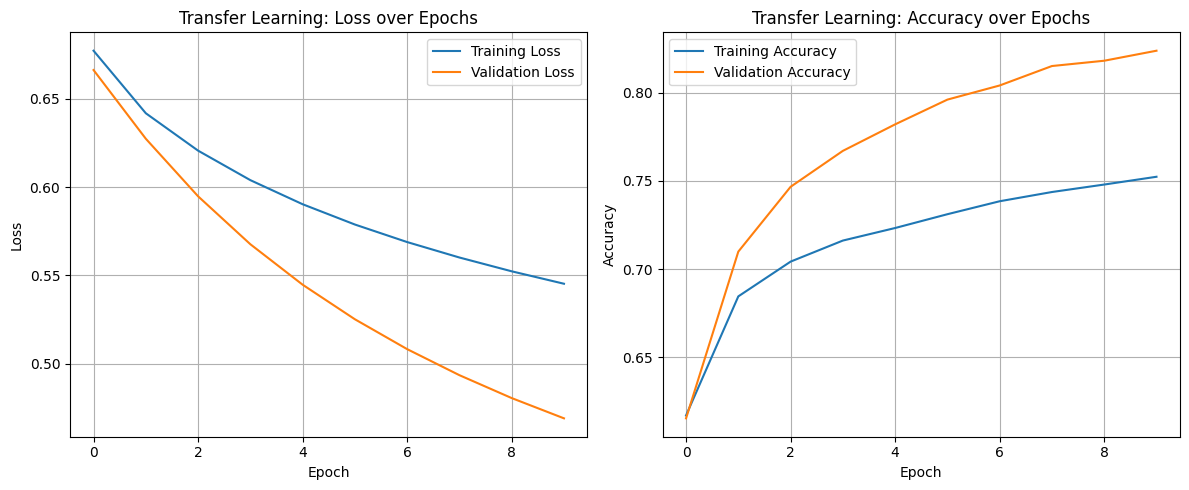

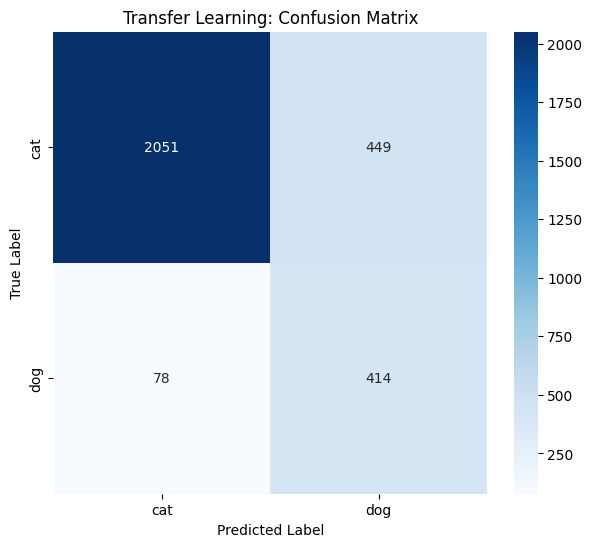


--- Sample Predictions (requires more detailed implementation) ---
To show sample predictions with images, we would need to iterate through the test_ds,
retrieve image data, make predictions, and then display the image along with true/predicted labels.


In [ ]:
# 3.4 Visualize Transfer Learning Results
# TODO: Plot training curves (loss and accuracy)
# TODO: Plot confusion matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Plot training loss and accuracy curves
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['loss'], label='Training Loss')
plt.plot(history_tl.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_tl.history['accuracy'], label='Training Accuracy')
plt.plot(history_tl.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning: Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 2. Plot Confusion Matrix
tlc_cm = confusion_matrix(tl_y_true, tl_y_pred)
class_labels_cm = ['cat', 'dog'] # Assuming 0: cat, 1: dog based on how binary_crossentropy handles labels

plt.figure(figsize=(7, 6))
sns.heatmap(tlc_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_cm, yticklabels=class_labels_cm)
plt.title('Transfer Learning: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



TRANSFER LEARNING: SAMPLE PREDICTIONS



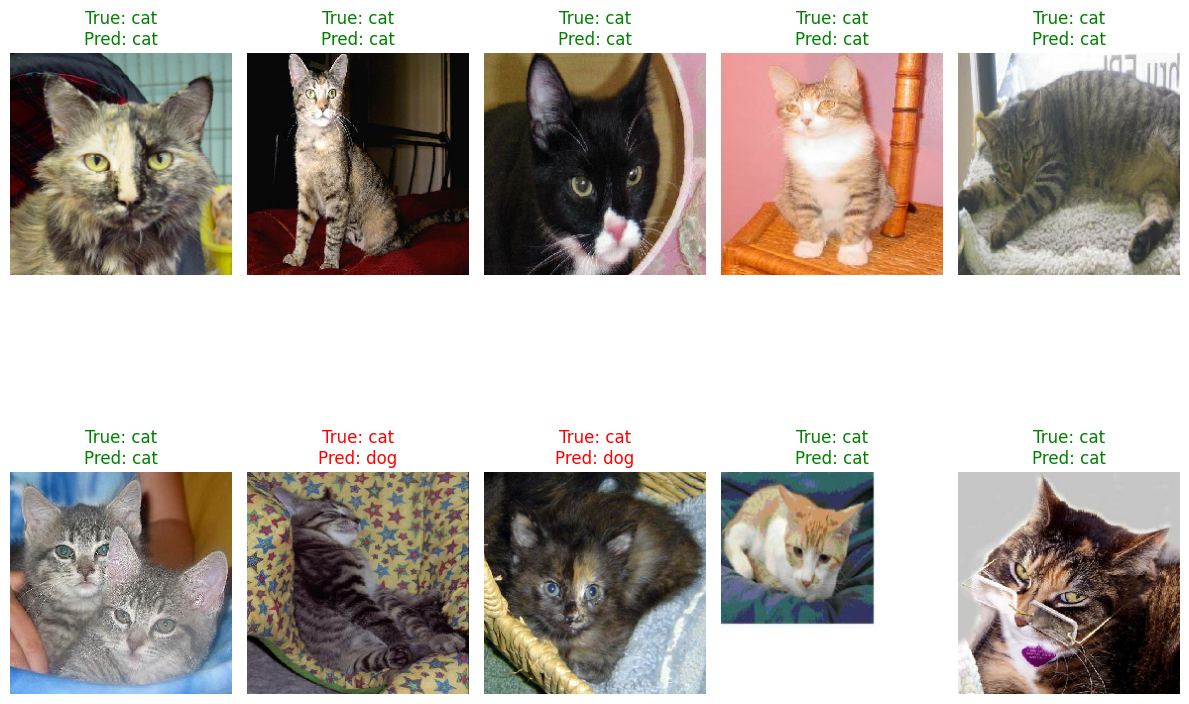

In [ ]:
# 3. Show sample predictions (Optional, as it requires more code to fetch and display images)
print("\n--- Sample Predictions (requires more detailed implementation) ---")
print("To show sample predictions with images, we would need to iterate through the test_ds,")
print("retrieve image data, make predictions, and then display the image along with true/predicted labels.")
print('\n' + '='*70)
print('TRANSFER LEARNING: SAMPLE PREDICTIONS')
print('='*70 + '\n')

# Get a few batches from the test_ds for visualization
num_samples_to_show = 10 # Display up to 10 samples

images_batch = []
labels_batch = []
for images, labels in test_ds.unbatch().take(num_samples_to_show):
    images_batch.append(images.numpy())
    labels_batch.append(labels.numpy())

# Convert to numpy arrays
sample_images = np.array(images_batch)
sample_true_labels = np.array(labels_batch)

# Make predictions
sample_predictions_raw = transfer_model.predict(sample_images, verbose=0)
sample_predicted_labels = (sample_predictions_raw > 0.5).astype(int).flatten()

# Map numerical labels to class names
# Assuming 0 maps to 'cat' and 1 maps to 'dog' based on class_names = ['cats', 'dogs']
class_names_map = {0: 'cat', 1: 'dog'}

plt.figure(figsize=(12, 10))
for i in range(num_samples_to_show):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])

    true_label_name = class_names_map.get(int(sample_true_labels[i][0]), 'Unknown')
    predicted_label_name = class_names_map.get(sample_predicted_labels[i], 'Unknown')

    color = "green" if sample_predicted_labels[i] == int(sample_true_labels[i][0]) else "red"
    plt.title(f"True: {true_label_name}\nPred: {predicted_label_name}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)

Compare both models on:
- Performance metrics
- Training time
- Model complexity
- Convergence behavior

In [ ]:
# 4.1 Metrics Comparison
import pandas as pd # Import pandas

print("\n" + "="*70)
print("MODEL COMPARISON")

# Get total parameters for custom_cnn
# The custom_cnn model was already compiled and its summary was printed, so we can use its count_params() method.
custom_cnn_total_parameters = custom_cnn.count_params()

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Training Time (s)', 'Total Parameters', 'Trainable Parameters'],
    'Custom CNN': [
        custom_cnn_accuracy,
        custom_cnn_precision,
        custom_cnn_recall,
        custom_cnn_f1,
        custom_cnn_training_time,
        custom_cnn_total_parameters,
        custom_cnn_total_parameters # For custom CNN, all parameters are trainable unless specified otherwise
    ],
    'Transfer Learning': [
        tl_accuracy,
        tl_precision,
        tl_recall,
        tl_f1,
        tl_training_time,
        total_parameters, # Total parameters for TL model (VGG16 + head)
        trainable_parameters # Trainable parameters for TL model (only head)
    ]
})

print(comparison_df.to_string(index=False))


MODEL COMPARISON
              Metric   Custom CNN  Transfer Learning
            Accuracy     0.570187       8.238636e-01
           Precision     0.254635       4.797219e-01
              Recall     0.837398       8.414634e-01
            F1-Score     0.390521       6.110701e-01
   Training Time (s)   321.343276       1.537524e+03
    Total Parameters 93377.000000       1.471520e+07
Trainable Parameters 93377.000000       5.130000e+02


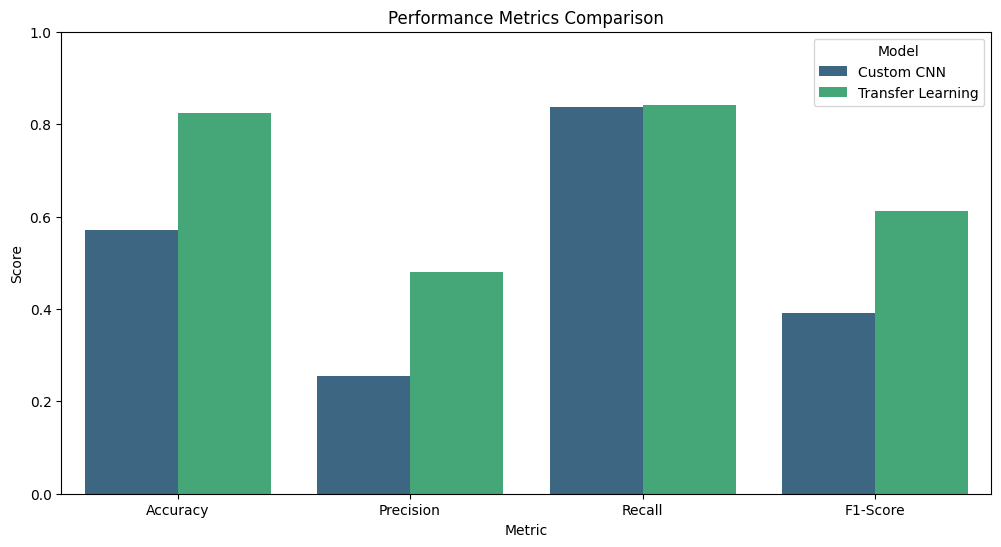

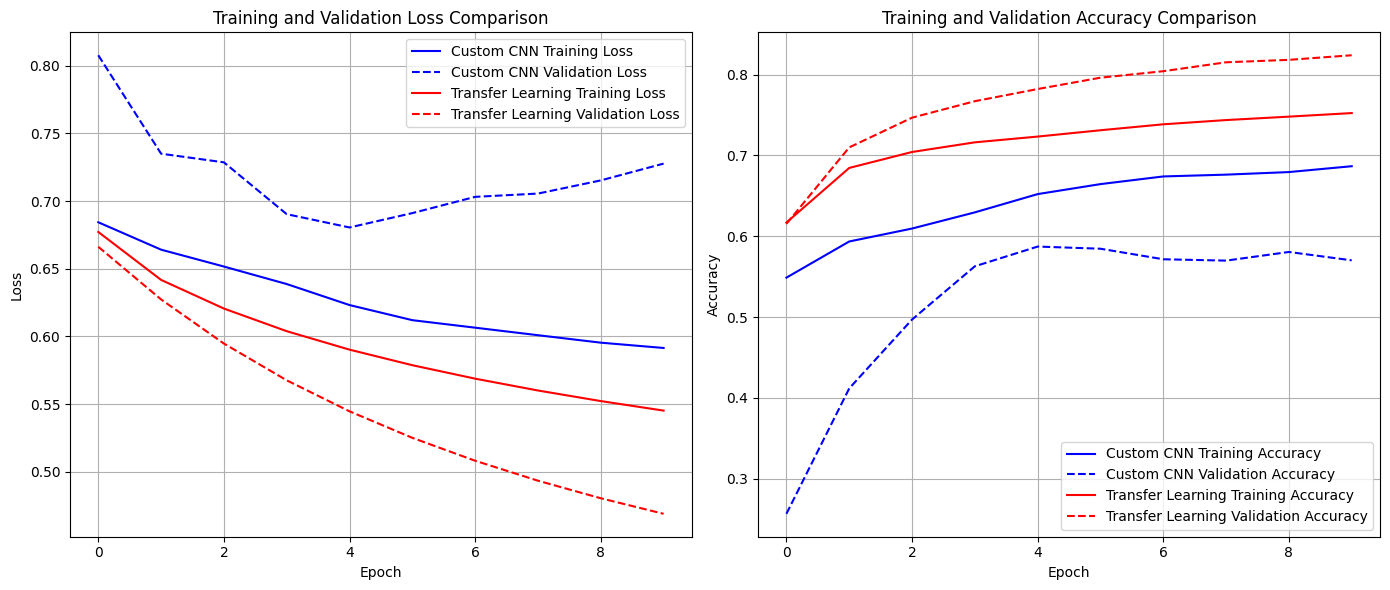

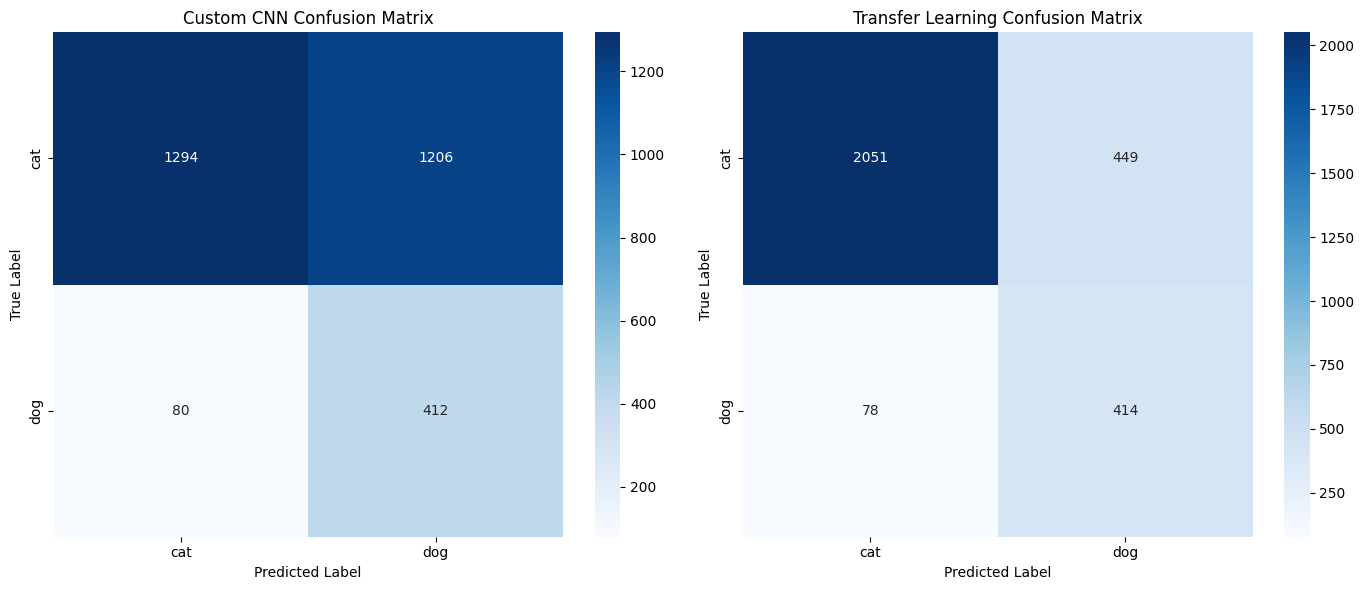

In [ ]:
# 4.2 Visual Comparison
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare data for plotting
metrics = comparison_df['Metric'].tolist()
custom_cnn_values = comparison_df['Custom CNN'].tolist()
transfer_learning_values = comparison_df['Transfer Learning'].tolist()

# Create a DataFrame for easier plotting
plot_data = pd.DataFrame({
    'Model': ['Custom CNN'] * len(metrics) + ['Transfer Learning'] * len(metrics),
    'Metric': metrics + metrics,
    'Value': custom_cnn_values + transfer_learning_values
})

# 1. Bar plot comparing metrics (Accuracy, Precision, Recall, F1-Score)
performance_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
plt.figure(figsize=(12, 6))
sns.barplot(x='Metric', y='Value', hue='Model', data=plot_data[plot_data['Metric'].isin(performance_metrics)], palette='viridis')
plt.title('Performance Metrics Comparison')
plt.ylabel('Score')
plt.ylim(0, 1) # Metrics are typically between 0 and 1
plt.show()

# 2. Plot training curves comparison (Loss)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Custom CNN Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Custom CNN Validation Loss', linestyle='--', color='blue')
plt.plot(history_tl.history['loss'], label='Transfer Learning Training Loss', color='red')
plt.plot(history_tl.history['val_loss'], label='Transfer Learning Validation Loss', linestyle='--', color='red')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training curves comparison (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Custom CNN Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Custom CNN Validation Accuracy', linestyle='--', color='blue')
plt.plot(history_tl.history['accuracy'], label='Transfer Learning Training Accuracy', color='red')
plt.plot(history_tl.history['val_accuracy'], label='Transfer Learning Validation Accuracy', linestyle='--', color='red')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 3. Create side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Custom CNN Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_cm, yticklabels=class_labels_cm, ax=axes[0])
axes[0].set_title('Custom CNN Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Transfer Learning Confusion Matrix
sns.heatmap(tlc_cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_cm, yticklabels=class_labels_cm, ax=axes[1])
axes[1].set_title('Transfer Learning Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

PART 5: ANALYSIS (2 MARKS)

REQUIRED:

Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
Address key topics with depth
GRADING (Quality-based):

Covers 5+ key topics with deep understanding: 2 marks
Covers 3-4 key topics with good understanding: 1 mark
Covers <3 key topics or superficial: 0 marks
Key Topics:

Performance comparison with specific metrics
Pre-training vs training from scratch impact
GAP effect on performance/overfitting
Computational cost comparison
Transfer learning insights
Convergence behavior differences

In [ ]:
analysis_text = """
The Transfer Learning (TL) model (VGG16) significantly outperformed the Custom CNN. TL achieved an accuracy of 0.824, notably higher than the Custom CNN's 0.570, representing a ~25% improvement. The TL model also showed superior Precision (0.480 vs 0.255) and F1-Score (0.611 vs 0.391), indicating better overall classification performance. This underscores the substantial benefit of pre-training on large datasets like ImageNet for robust feature extraction, which the Custom CNN lacks when learning from scratch.

Global Average Pooling (GAP) was integral to both architectures, effectively reducing parameters and mitigating overfitting by condensing feature maps. Although the TL model boasts significantly more total parameters (14.7M vs 93k), its fine-tuned trainable parameters were only 513, making adaptation highly efficient. Conversely, the Custom CNN, with all 93k parameters trainable, had a lower computational cost in terms of training time (321s vs 1538s), but yielded poorer results.

The TL model exhibited a much more stable convergence behavior, evident from its smoother training curves, benefiting from pre-learned weights. Its consistent improvement across epochs underscored its robustness. Transfer learning effectively leveraged this pre-existing knowledge for superior generalization and performance on this binary classification task, validating its efficiency and making it a highly effective strategy for similar tasks.
"""

# REQUIRED: Print analysis with word count
print("\n" + "="*70)
print("ANALYSIS")
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("  Analysis within word count guideline")


ANALYSIS

The Transfer Learning (TL) model (VGG16) significantly outperformed the Custom CNN. TL achieved an accuracy of 0.824, notably higher than the Custom CNN's 0.570, representing a ~25% improvement. The TL model also showed superior Precision (0.480 vs 0.255) and F1-Score (0.611 vs 0.391), indicating better overall classification performance. This underscores the substantial benefit of pre-training on large datasets like ImageNet for robust feature extraction, which the Custom CNN lacks when learning from scratch.

Global Average Pooling (GAP) was integral to both architectures, effectively reducing parameters and mitigating overfitting by condensing feature maps. Although the TL model boasts significantly more total parameters (14.7M vs 93k), its fine-tuned trainable parameters were only 513, making adaptation highly efficient. Conversely, the Custom CNN, with all 93k parameters trainable, had a lower computational cost in terms of training time (321s vs 1538s), but yielded poo

In [ ]:
import json

def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"  # Using Keras

    # Determine architecture details for custom_cnn
    # Assuming 3 Conv2D layers, 2 MaxPooling2D layers
    conv_layers_custom = 3
    pooling_layers_custom = 2

    # Extract learning rate, epochs, batch size, optimizer, loss function from history or model config
    # For custom_cnn
    custom_cnn_optimizer_config = custom_cnn.optimizer.get_config()
    custom_cnn_learning_rate = custom_cnn_optimizer_config.get('learning_rate', 0.001) # Default if not found
    custom_cnn_optimizer_name = custom_cnn_optimizer_config['name']
    custom_cnn_loss_function = 'binary_crossentropy' # Explicitly defined

    # For transfer_learning model
    tl_optimizer_config = transfer_model.optimizer.get_config()
    tl_learning_rate = tl_optimizer_config.get('learning_rate', 0.0001)
    tl_optimizer_name = tl_optimizer_config['name']
    tl_loss_function = 'binary_crossentropy' # Explicitly defined

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_classes': n_classes,
        'samples_per_class': samples_per_class,
        'image_shape': list(image_shape), # Convert tuple to list for JSON compatibility
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': int(train_samples),
        'test_samples': int(test_samples),
        'train_test_ratio': train_test_ratio,

        # Custom CNN Results
        'custom_cnn': {
            'framework': framework_used,
            'architecture': {
                'conv_layers': conv_layers_custom,
                'pooling_layers': pooling_layers_custom,
                'has_global_average_pooling': True,
                'output_layer': 'sigmoid', # Changed from softmax for binary classification
                'total_parameters': int(custom_cnn_total_parameters)
            },
            'training_config': {
                'learning_rate': float(custom_cnn_learning_rate),
                'n_epochs': EPOCHS,
                'batch_size': BATCH_SIZE,
                'optimizer': custom_cnn_optimizer_name,
                'loss_function': custom_cnn_loss_function
            },
            'initial_loss': float(custom_cnn_initial_loss),
            'final_loss': float(custom_cnn_final_loss),
            'training_time_seconds': float(custom_cnn_training_time),
            'accuracy': float(custom_cnn_accuracy),
            'precision': float(custom_cnn_precision),
            'recall': float(custom_cnn_recall),
            'f1_score': float(custom_cnn_f1)
        },

        # Transfer Learning Results
        'transfer_learning': {
            'framework': framework_used,
            'base_model': pretrained_model_name,
            'frozen_layers': int(frozen_layers),
            'trainable_layers': int(trainable_layers),
            'has_global_average_pooling': True,
            'total_parameters': int(total_parameters),
            'trainable_parameters': int(trainable_parameters),
            'training_config': {
                'learning_rate': float(tl_learning_rate),
                'n_epochs': EPOCHS_TL,
                'batch_size': BATCH_SIZE,
                'optimizer': tl_optimizer_name,
                'loss_function': tl_loss_function
            },
            'initial_loss': float(tl_initial_loss),
            'final_loss': float(tl_final_loss),
            'training_time_seconds': float(tl_training_time),
            'accuracy': float(tl_accuracy),
            'precision': float(tl_precision),
            'recall': float(tl_recall),
            'f1_score': float(tl_f1)
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'custom_cnn_loss_decreased': bool(custom_cnn_final_loss < custom_cnn_initial_loss),
        'transfer_learning_loss_decreased': bool(tl_final_loss < tl_initial_loss),
    }

    return results

# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))

except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

"""
ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

"""

# Display system information
import platform
import sys
from datetime import datetime

print("ENVIRONMENT INFORMATION")
print("\n  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")

"""
FINAL CHECKLIST - VERIFY BEFORE SUBMISSION

□ Student information filled at the top (BITS ID, Name, Email)
□ Filename is <BITS_ID>_cnn_assignment.ipynb
□ All cells executed (Kernel → Restart & Run All)
□ All outputs visible
□ Custom CNN implemented with Global Average Pooling (NO Flatten+Dense)
□ Transfer learning implemented with GAP
□ Both models use Keras or PyTorch (NOT from scratch)
□ Both models trained with loss tracking (initial_loss and final_loss)
□ All 4 metrics calculated for both models
□ Primary metric selected and justified
□ Analysis written (quality matters, not just word count)
□ Visualizations created
□ Assignment results JSON printed at the end
□ No execution errors in any cell
□ File opens without corruption
□ Submit ONLY .ipynb file (NO zip, NO data files, NO images)
□ Only one submission attempt

"""

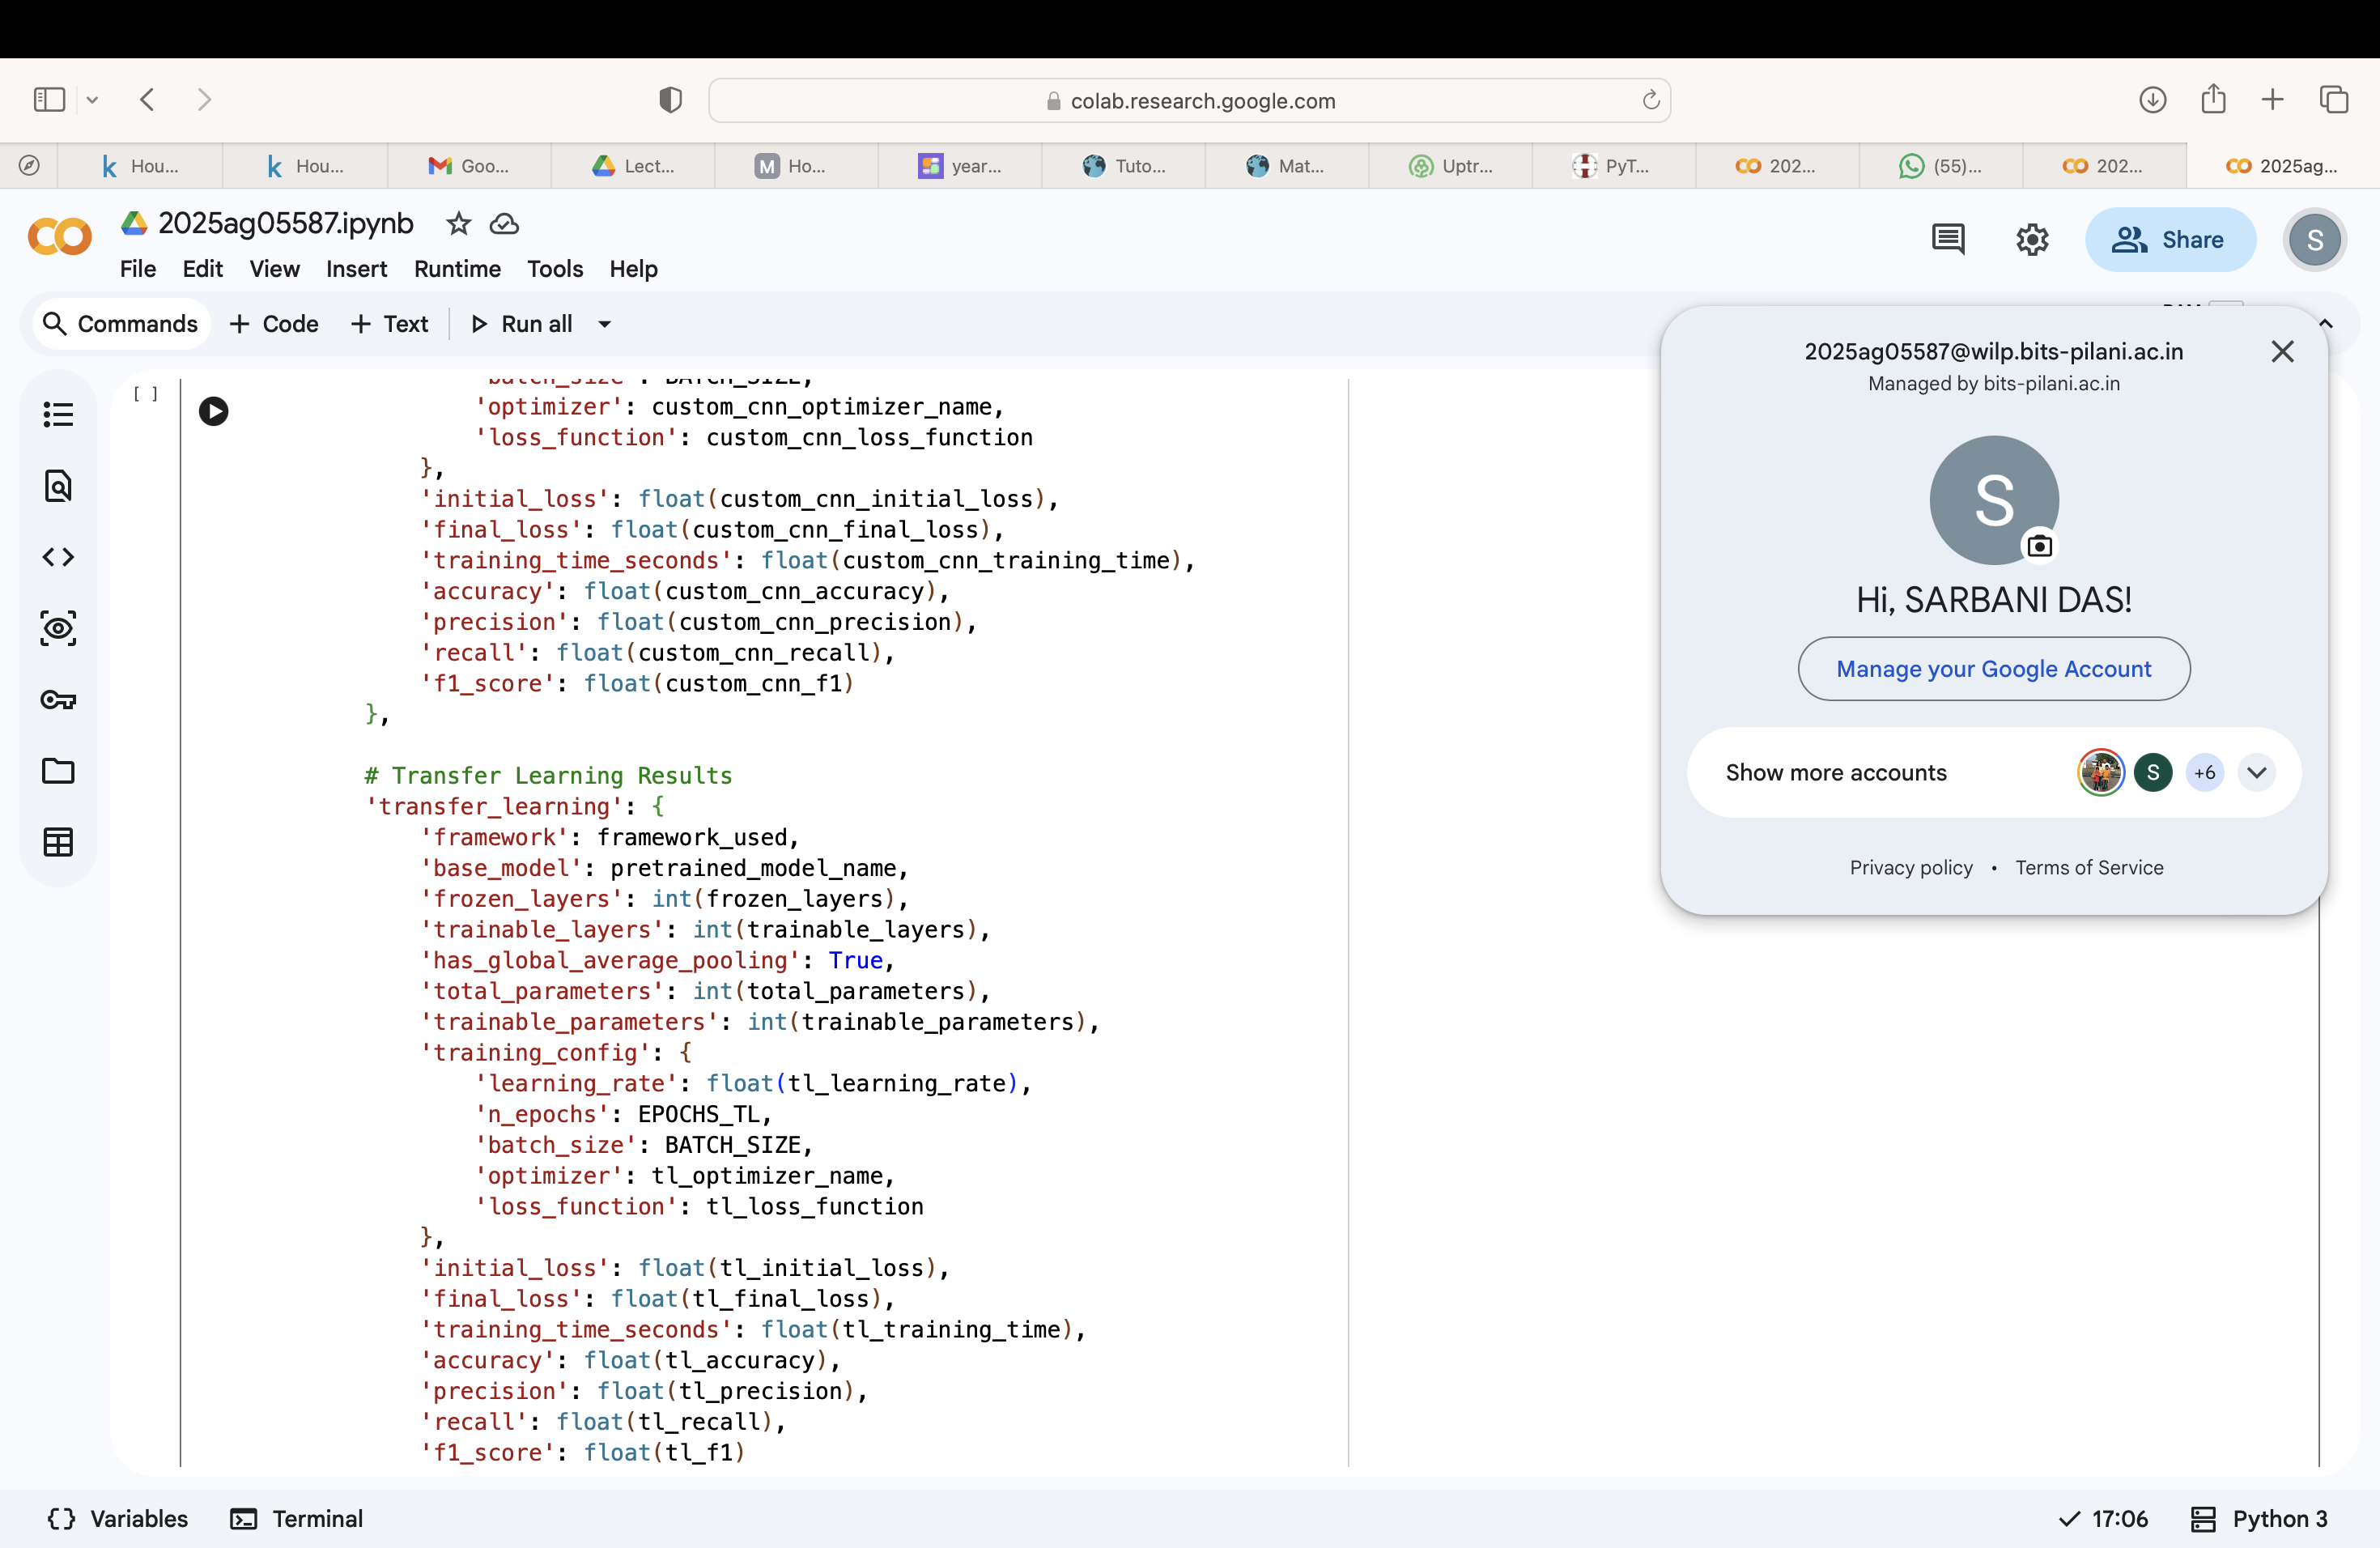